# Platt scaling e regressão isotônica

**Tema:** Avaliação e Validação de Modelos › Calibração de Probabilidades

O notebook anterior mostrou que um modelo pode ordenar bem e ainda
devolver probabilidades que não valem nada. Este notebook conserta:
implementa do zero os dois métodos clássicos de recalibração (Platt
scaling e regressão isotônica), mostra onde cada um falha, mede quanto
dado cada um precisa, demonstra o erro de calibrar na base de treino e
fecha traduzindo a calibração para dinheiro, com o limiar de custo do
módulo 1.

## A ideia

Recalibrar é aprender uma função **monótona** $g$ que leva o escore do
modelo, $s = \hat{p}(x)$, a uma probabilidade honesta, $g(s)$. Monótona
porque a ordem do modelo é a parte que funciona; queremos consertar a
escala sem mexer no ranking. Por ser um ajuste, $g$ precisa ser
aprendida em dados que o modelo **não viu no treino**, e avaliada num
terceiro conjunto. Três conjuntos, três papéis: treino do modelo,
calibração, teste.

**Analogia.** Um termômetro que marca sempre 3 graus a mais ordena os
dias corretamente (o dia mais quente marca mais), mas todas as leituras
estão erradas. Você não joga o termômetro fora: descobre a correção
comparando-o com um termômetro de referência em alguns dias, e passa a
subtrair 3. Platt e isotônica são dois jeitos de descobrir a correção:
um assume que ela tem uma forma específica (dois parâmetros); o outro
só assume que "mais quente no termômetro é mais quente de verdade".

### O que você vai conseguir fazer ao final

- Implementar Platt scaling e o algoritmo PAVA da regressão isotônica.
- Escolher entre os dois pelo tamanho da base de calibração e pela forma
  da distorção.
- Usar `CalibratedClassifierCV` sabendo o que ele faz por dentro.
- Explicar por que calibrar na base de treino não funciona.
- Converter uma melhoria de calibração em resultado financeiro.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.special import expit, logit
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.frozen import FrozenEstimator
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score
from sklearn.naive_bayes import GaussianNB

rng = np.random.default_rng(652)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR, CINZA = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100", "#5A5A5A"
print("pronto")

pronto


## 1. A mesma base e os dois modelos descalibrados

Reaproveitamos o gerador de crédito do notebook anterior e os dois
modelos que saíram piores: o boosting sem freio (superconfiante) e o
naive Bayes (extremos demais por causa das features redundantes).
`MODELO` escolhe qual recalibrar; `N_CALIB` é o tamanho da base de
calibração. Os dois estão expostos para você mudar.

In [2]:
MODELO = "boosting sem freio"          # ou "naive Bayes"
N_CALIB = 2000

def gera_credito(n, semente, intercepto=-1.2):
    g = np.random.default_rng(semente)
    Z = g.normal(0, 1, (n, 4))
    lg = intercepto + 1.8 * Z[:, 0] - 1.4 * Z[:, 1] + 1.0 * Z[:, 2] + 1.2 * Z[:, 0] * Z[:, 1] + 0.6 * Z[:, 3]
    p = 1 / (1 + np.exp(-lg))
    copias = np.column_stack([Z[:, 0] + g.normal(0, 0.4, n), Z[:, 0] + g.normal(0, 0.4, n),
                              Z[:, 1] + g.normal(0, 0.4, n), Z[:, 1] + g.normal(0, 0.4, n)])
    return np.column_stack([Z, copias]), (g.random(n) < p).astype(int), p

def diagrama(y, p, n_bins=10):
    bordas = np.quantile(p, np.linspace(0, 1, n_bins + 1)); bordas[0], bordas[-1] = 0, 1
    qual = np.clip(np.searchsorted(bordas, p, side="right") - 1, 0, n_bins - 1)
    return pd.DataFrame([{"previsão média": p[qual == b].mean(), "frequência observada": y[qual == b].mean(),
                          "n": int((qual == b).sum())} for b in range(n_bins) if (qual == b).sum()])

def ece(y, p, n_bins=10):
    d = diagrama(y, p, n_bins)
    return float(np.sum(d["n"] / len(y) * np.abs(d["previsão média"] - d["frequência observada"])))

def resumo(y, p):
    return {"AUC": roc_auc_score(y, p), "Brier": brier_score_loss(y, p), "log loss": log_loss(y, p), "ECE": ece(y, p)}

def desenha(ax, y, p, rotulo, cor, n_bins=10):
    d = diagrama(y, p, n_bins)
    ax.plot(d["previsão média"], d["frequência observada"], marker="o", ms=5, lw=1.8, color=cor,
            label=f"{rotulo} (ECE {ece(y, p, n_bins):.3f})")

fabricas = {"boosting sem freio": lambda: HistGradientBoostingClassifier(max_iter=500, learning_rate=0.3, random_state=0),
            "naive Bayes": lambda: GaussianNB()}
X_tr, y_tr, _ = gera_credito(6000, 11)
X_cal, y_cal, _ = gera_credito(N_CALIB, 12)
X_te, y_te, p_te = gera_credito(20000, 13)
modelo = fabricas[MODELO]().fit(X_tr, y_tr)
s_cal, s_te, s_tr = (modelo.predict_proba(X)[:, 1] for X in (X_cal, X_te, X_tr))
print(f"{MODELO} sem calibrar, no teste: " + " | ".join(f"{k} {v:.4f}" for k, v in resumo(y_te, s_te).items()))
print(f"oráculo (p verdadeira)        : Brier {brier_score_loss(y_te, p_te):.4f}")

boosting sem freio sem calibrar, no teste: AUC 0.8586 | Brier 0.1851 | log loss 0.9452 | ECE 0.1583
oráculo (p verdadeira)        : Brier 0.1299


## 2. Platt scaling do zero

Platt (1999) propôs ajustar uma sigmoide ao escore:

$$g(s) = \frac{1}{1 + e^{-(a\,s + b)}}$$

com $a$ e $b$ escolhidos por máxima verossimilhança na base de
calibração, que é o mesmo que ajustar uma regressão logística com uma
única feature, $s$. Dois parâmetros: $a$ estica ou comprime a escala
($a < 1$ sobre o logit "acalma" um modelo superconfiante), $b$ desloca.
Pouquíssimos parâmetros significam que Platt funciona com algumas
centenas de casos e quase não sobreajusta; em troca, só conserta
distorções com forma de sigmoide.

Quando o escore já é uma probabilidade, a prática comum é aplicar a
sigmoide sobre o **logit** de $s$, e não sobre $s$: aí $a = 1, b = 0$ é
a identidade e a correção parte de "não mexer". Platt também sugeriu um
truque para não sobreajustar as pontas: em vez dos rótulos 0 e 1, usar
alvos suavizados $\frac{N_+ + 1}{N_+ + 2}$ e $\frac{1}{N_- + 2}$, que
são a estimativa bayesiana da frequência com uma priori uniforme.

In [3]:
def platt_ajusta(s, y, suaviza=True):
    z = logit(np.clip(s, 1e-6, 1 - 1e-6))
    n_pos, n_neg = y.sum(), len(y) - y.sum()
    alvo = np.where(y == 1, (n_pos + 1) / (n_pos + 2), 1 / (n_neg + 2)) if suaviza else y.astype(float)
    def perda(theta):
        p = expit(theta[0] * z + theta[1])
        return -np.mean(alvo * np.log(p) + (1 - alvo) * np.log(1 - p))
    a, b = minimize(perda, x0=[1.0, 0.0], method="BFGS").x
    return a, b

def platt_aplica(s, a, b):
    return expit(a * logit(np.clip(s, 1e-6, 1 - 1e-6)) + b)

a, b = platt_ajusta(s_cal, y_cal)
p_platt = platt_aplica(s_te, a, b)
print(f"Platt: a = {a:.3f}, b = {b:+.3f}   (a < 1 comprime: o modelo era superconfiante)")
print("teste: " + " | ".join(f"{k} {v:.4f}" for k, v in resumo(y_te, p_platt).items()))

Platt: a = 0.221, b = -0.251   (a < 1 comprime: o modelo era superconfiante)
teste: AUC 0.8585 | Brier 0.1494 | log loss 0.4547 | ECE 0.0284


## 3. Regressão isotônica do zero: o algoritmo PAVA

Zadrozny e Elkan (2002) propuseram não assumir forma nenhuma: encontrar
a função **monótona não decrescente** que melhor ajusta (em erro
quadrático) os pares (escore, rótulo) da base de calibração. A solução
é uma escada, e o algoritmo que a encontra é o PAVA (*pool adjacent
violators*):

1. Ordene os casos pelo escore e comece com um "bloco" por caso, cujo
   valor é o rótulo (0 ou 1).
2. Percorra os blocos. Sempre que um bloco tiver valor **maior** que o
   seguinte (uma violação da monotonicidade), funda os dois num só, com
   valor igual à média ponderada.
3. Repita até não haver violações. Cada bloco vira um degrau da escada.

O resultado é a frequência observada de positivos em faixas do escore,
com as faixas escolhidas pelos dados. Sem parâmetros para limitar a
forma, a isotônica conserta qualquer distorção monótona, e também
ajusta o ruído: com poucos casos, a escada tem degraus que são acaso.

In [4]:
def pava(s, y):
    """Devolve os degraus (limite superior do escore, valor) da regressão isotônica de y em s."""
    ordem = np.argsort(s, kind="stable")
    valores, pesos, limites = list(y[ordem].astype(float)), [1.0] * len(y), list(s[ordem])
    i = 0
    while i < len(valores) - 1:
        if valores[i] > valores[i + 1]:                     # violação: funde com o próximo
            peso = pesos[i] + pesos[i + 1]
            valores[i] = (valores[i] * pesos[i] + valores[i + 1] * pesos[i + 1]) / peso
            pesos[i] = peso
            limites[i] = limites[i + 1]
            del valores[i + 1], pesos[i + 1], limites[i + 1]
            i = max(i - 1, 0)                                # a fusão pode ter criado violação atrás
        else:
            i += 1
    return np.array(limites), np.array(valores)

def isotonica_aplica(s, limites, valores):
    return valores[np.clip(np.searchsorted(limites, s, side="left"), 0, len(valores) - 1)]

limites, valores = pava(s_cal, y_cal)
p_iso = isotonica_aplica(s_te, limites, valores)
iso_sk = IsotonicRegression(out_of_bounds="clip").fit(s_cal, y_cal)
print(f"PAVA do zero: {len(valores)} degraus | diferença máxima para o sklearn nos pontos de calibração: "
      f"{np.max(np.abs(isotonica_aplica(s_cal, limites, valores) - iso_sk.predict(s_cal))):.2e}")
print("teste: " + " | ".join(f"{k} {v:.4f}" for k, v in resumo(y_te, p_iso).items()))

PAVA do zero: 193 degraus | diferença máxima para o sklearn nos pontos de calibração: 2.22e-16
teste: AUC 0.8578 | Brier 0.1495 | log loss 0.4652 | ECE 0.0217


Nos pontos de calibração as duas implementações coincidem. Fora deles,
o `scikit-learn` faz uma escolha a mais: em vez da escada, **interpola
linearmente** entre os degraus, o que suaviza a função para escores
novos. É um refinamento; o objeto ajustado é o mesmo.

## 4. Antes e depois

Os dois métodos lado a lado, no diagrama e nos números. Repare na AUC:
Platt não a muda (uma sigmoide é estritamente crescente); a isotônica
a reduz um pouco, porque a escada cria **empates** entre casos que
tinham escores diferentes.

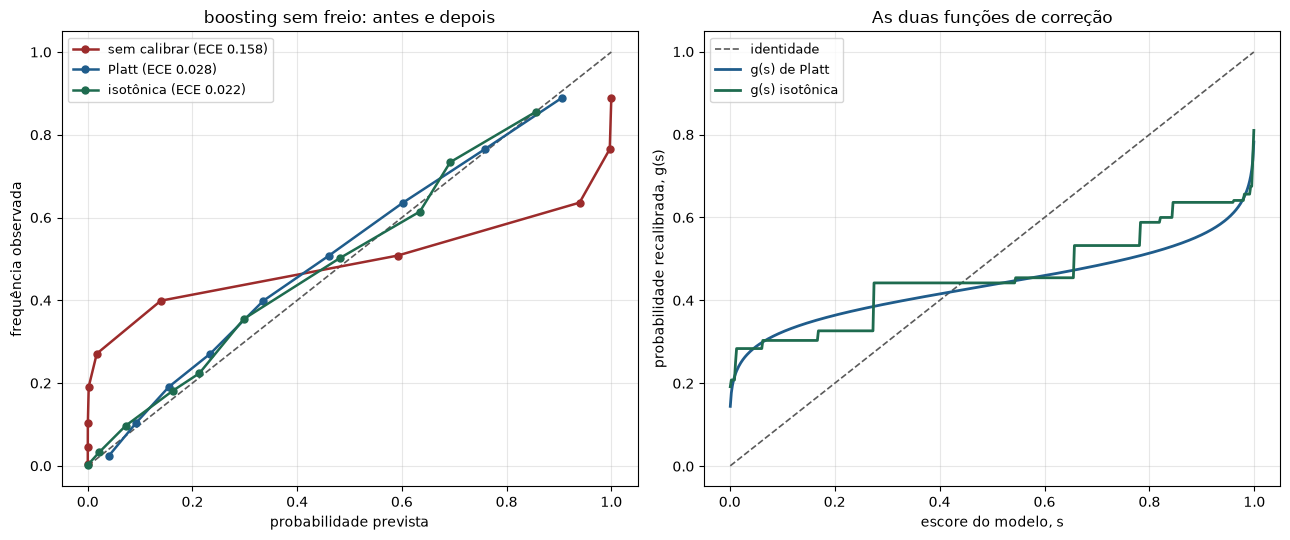

                 AUC   Brier  log loss     ECE
sem calibrar  0.8586  0.1851    0.9452  0.1583
Platt         0.8585  0.1494    0.4547  0.0284
isotônica     0.8578  0.1495    0.4652  0.0217


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
ax = axes[0]
ax.plot([0, 1], [0, 1], color=CINZA, ls="--", lw=1.2)
desenha(ax, y_te, s_te, "sem calibrar", VERMELHO)
desenha(ax, y_te, p_platt, "Platt", AZUL)
desenha(ax, y_te, p_iso, "isotônica", VERDE)
ax.set_xlabel("probabilidade prevista"); ax.set_ylabel("frequência observada"); ax.legend(fontsize=9)
ax.set_title(f"{MODELO}: antes e depois")

ax = axes[1]
grade = np.linspace(0.001, 0.999, 500)
ax.plot(grade, grade, color=CINZA, ls="--", lw=1.2, label="identidade")
ax.plot(grade, platt_aplica(grade, a, b), color=AZUL, lw=2, label="g(s) de Platt")
ax.plot(grade, isotonica_aplica(grade, limites, valores), color=VERDE, lw=2, label="g(s) isotônica")
ax.set_xlabel("escore do modelo, s"); ax.set_ylabel("probabilidade recalibrada, g(s)"); ax.legend(fontsize=9)
ax.set_title("As duas funções de correção")
plt.tight_layout(); plt.show()

tabela = pd.DataFrame({"sem calibrar": resumo(y_te, s_te), "Platt": resumo(y_te, p_platt),
                       "isotônica": resumo(y_te, p_iso)}).T
print(tabela.round(4).to_string())

**Leitura esperada:** as duas curvas de correção são achatadas nas
pontas (um escore de 0,99 vira algo como 0,85) e passam perto da
identidade no meio. A isotônica é uma escada que segue a de Platt de
perto, com degraus que são os dados falando, alguns deles ruído. No
teste, os dois métodos cortam o ECE por três ou mais e aproximam o Brier
do oráculo. Com `N_CALIB = 2000`, o empate é a regra; o que separa os
dois aparece na próxima seção.

## 5. Quanto dado cada método precisa

Repetimos a calibração com bases de 50 a 10.000 casos, 20 sementes cada,
e medimos o Brier no teste. É a curva de aprendizado (módulo anterior)
do calibrador.

        Platt         isotônica        
         mean     std      mean     std
n                                      
50     0.1546  0.0063    0.1638  0.0078
100    0.1525  0.0044    0.1590  0.0048
200    0.1506  0.0022    0.1551  0.0035
500    0.1492  0.0008    0.1514  0.0011
1000   0.1489  0.0004    0.1502  0.0006
2000   0.1488  0.0002    0.1495  0.0005
5000   0.1487  0.0002    0.1488  0.0002
10000  0.1487  0.0001    0.1486  0.0001


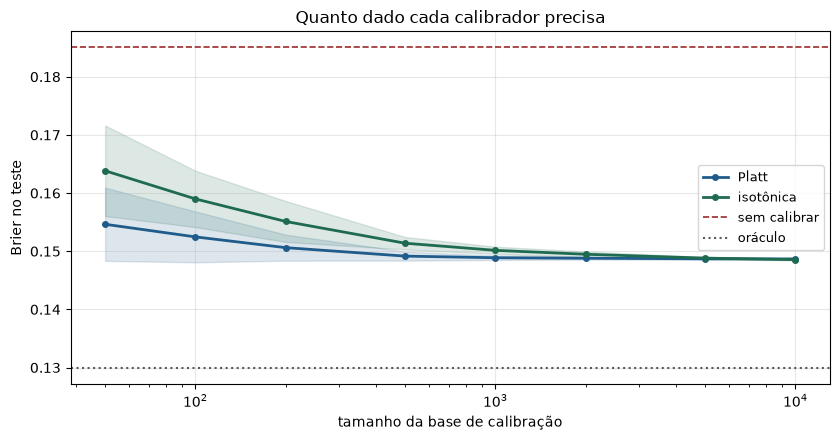

In [6]:
tamanhos = [50, 100, 200, 500, 1000, 2000, 5000, 10000]
X_pool, y_pool, _ = gera_credito(60000, 14)
s_pool = modelo.predict_proba(X_pool)[:, 1]
linhas = []
for n in tamanhos:
    for sem in range(20):
        idx = np.random.default_rng(sem).choice(len(y_pool), n, replace=False)
        a_, b_ = platt_ajusta(s_pool[idx], y_pool[idx])
        lim_, val_ = pava(s_pool[idx], y_pool[idx])
        linhas.append({"n": n, "Platt": brier_score_loss(y_te, platt_aplica(s_te, a_, b_)),
                       "isotônica": brier_score_loss(y_te, isotonica_aplica(s_te, lim_, val_))})
curva = pd.DataFrame(linhas).groupby("n").agg(["mean", "std"])
print(curva.round(4).to_string())

fig, ax = plt.subplots(figsize=(8.5, 4.5))
for metodo, cor in [("Platt", AZUL), ("isotônica", VERDE)]:
    m, sd = curva[(metodo, "mean")], curva[(metodo, "std")]
    ax.plot(tamanhos, m, color=cor, lw=2, marker="o", ms=4, label=metodo)
    ax.fill_between(tamanhos, m - sd, m + sd, color=cor, alpha=0.15)
ax.axhline(brier_score_loss(y_te, s_te), color=VERMELHO, ls="--", lw=1.2, label="sem calibrar")
ax.axhline(brier_score_loss(y_te, p_te), color=CINZA, ls=":", lw=1.5, label="oráculo")
ax.set_xscale("log"); ax.set_xlabel("tamanho da base de calibração"); ax.set_ylabel("Brier no teste")
ax.set_title("Quanto dado cada calibrador precisa"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

**Leitura esperada:** os dois métodos já melhoram o modelo com 50
casos, porque a distorção aqui é grosseira e qualquer correção ajuda.
Mas a isotônica fica bem atrás de Platt até uns 2.000 casos, com o
dobro da variância entre sementes: uma escada ajustada a 50 rótulos tem
degraus que são ruído. Platt, com dois parâmetros, estabiliza perto de
500. A partir de alguns milhares os dois convergem, e a isotônica só
passa à frente se a distorção tiver alguma forma que a sigmoide não
capture. A regra prática de Niculescu-Mizil e Caruana: Platt abaixo de
~1.000 casos de calibração, isotônica acima.

Troque `MODELO` para `"naive Bayes"` e rode de novo: a distorção do
naive Bayes é mais assimétrica, e a isotônica com bases grandes ganha
terreno.

## 6. O erro clássico: calibrar na base de treino

Um modelo superconfiante é superconfiante **e correto** na sua própria
base de treino: ele memorizou os rótulos. Um calibrador ajustado ali
aprende que "0,99 significa 99%", porque no treino significa mesmo.
Platt aprende a identidade, e o teste continua descalibrado. A
isotônica vai além: como no treino o escore acerta o rótulo quase
sempre, ela aprende uma escada de um degrau só, de 0 para 1, e devolve
probabilidades de exatamente 0 e 1, o pior caso possível para a log
loss.

In [7]:
lim_tr, val_tr = pava(s_tr, y_tr)
a_tr, b_tr = platt_ajusta(s_tr, y_tr)
print("calibrador ajustado na base de TREINO, avaliado no teste:")
for nome, p in [("sem calibrar", s_te), ("Platt (treino)", platt_aplica(s_te, a_tr, b_tr)),
                ("isotônica (treino)", isotonica_aplica(s_te, lim_tr, val_tr))]:
    print(f"  {nome:>20s}: Brier {brier_score_loss(y_te, p):.4f} | ECE {ece(y_te, p):.4f}")
print(f"  (Platt aprendeu a = {a_tr:.2f}, b = {b_tr:+.2f}: quase a identidade)")
print("\ncalibrador ajustado na base de CALIBRAÇÃO (seção 4):")
print(f"  {'Platt':>20s}: Brier {brier_score_loss(y_te, p_platt):.4f} | ECE {ece(y_te, p_platt):.4f}")

calibrador ajustado na base de TREINO, avaliado no teste:
          sem calibrar: Brier 0.1851 | ECE 0.1583
        Platt (treino): Brier 0.1874 | ECE 0.1624
    isotônica (treino): Brier 0.2663 | ECE 0.2663
  (Platt aprendeu a = 1.09, b = +0.00: quase a identidade)

calibrador ajustado na base de CALIBRAÇÃO (seção 4):
                 Platt: Brier 0.1494 | ECE 0.0284


Quando não há dados de sobra para uma base de calibração separada, o
`scikit-learn` resolve com validação cruzada: `CalibratedClassifierCV`
com `cv=5` treina cinco modelos, cada um em 4/5 dos dados, calibra cada
um no quinto restante e, na previsão, **tira a média dos cinco
calibrados**. Nenhum calibrador vê dados que seu modelo treinou, e todos
os dados são usados nas duas tarefas. O custo é treinar cinco modelos
em vez de um, e o produto final é um comitê.

Quando o modelo já está treinado e existe uma base de calibração, o
caminho é `FrozenEstimator`: congela o modelo e o
`CalibratedClassifierCV` só ajusta o calibrador.

In [8]:
cv_platt = CalibratedClassifierCV(fabricas[MODELO](), method="sigmoid", cv=5).fit(X_tr, y_tr)
cv_iso = CalibratedClassifierCV(fabricas[MODELO](), method="isotonic", cv=5).fit(X_tr, y_tr)
congelado = CalibratedClassifierCV(FrozenEstimator(modelo), method="isotonic").fit(X_cal, y_cal)
for nome, m in [("cv=5, Platt (comitê de 5)", cv_platt), ("cv=5, isotônica (comitê de 5)", cv_iso),
                ("modelo congelado + isotônica na base de calibração", congelado)]:
    p = m.predict_proba(X_te)[:, 1]
    print(f"{nome:>52s}: Brier {brier_score_loss(y_te, p):.4f} | ECE {ece(y_te, p):.4f} | AUC {roc_auc_score(y_te, p):.4f}")

                           cv=5, Platt (comitê de 5): Brier 0.1434 | ECE 0.0138 | AUC 0.8680


                       cv=5, isotônica (comitê de 5): Brier 0.1435 | ECE 0.0077 | AUC 0.8675
  modelo congelado + isotônica na base de calibração: Brier 0.1495 | ECE 0.0218 | AUC 0.8578


O comitê de cinco costuma sair um pouco **melhor** que o modelo único
calibrado, e não é por causa da calibração: é o efeito de bagging do
módulo anterior, cinco modelos superconfiantes com a média entre eles
reduzindo a variância. É um efeito colateral bem-vindo, mas vale saber
de onde vem.

## 7. Outros calibradores, em uma linha cada

| Método | Parâmetros | Quando |
| :-- | :-- | :-- |
| Platt (sigmoide) | 2 | poucos dados; distorção com forma de S |
| Isotônica | livre (escada) | milhares de casos; qualquer distorção monótona |
| Temperature scaling (Guo et al., 2017) | 1: divide o logit por $T$ | redes neurais multiclasse; um só parâmetro que não muda a classe prevista |
| Beta calibration (Kull et al., 2017) | 3 | como Platt, mas consegue corrigir distorções assimétricas |
| Correção de priori (notebook anterior) | 0: usa as prevalências | quando a única distorção é reamostragem ou peso de classe |

Todos são monótonos e todos precisam de dados que o modelo não viu.

## 8. Calibração em dinheiro

O módulo 1 mostrou que, com custos $C_{FP}$ e $C_{FN}$, o limiar ótimo
sobre a probabilidade é $C_{FP} / (C_{FP} + C_{FN})$. A conta assume que a
probabilidade é honesta. Vamos aplicá-la a uma carteira em que negar um
bom pagador custa a margem ($C_{FP} = 0{,}1 \cdot v$) e aprovar um mau
pagador custa a perda ($C_{FN} = 0{,}7 \cdot v$), com $v$ o valor do
empréstimo. O limiar teórico é 0,125.

In [9]:
C_FP, C_FN = 0.10, 0.70
limiar = C_FP / (C_FP + C_FN)
v = rng.gamma(3, 4000, len(y_te))                          # valor de cada empréstimo

def lucro(p, y, v, t):
    aprova = p < t
    return np.sum(np.where(aprova, np.where(y == 1, -0.70 * v, 0.10 * v), 0.0))   # margem se paga, perda se não

print(f"limiar teórico: {limiar:.3f}\n")
for nome, p in [("sem calibrar", s_te), ("Platt", p_platt), ("isotônica", p_iso), ("oráculo", p_te)]:
    aprovados = np.mean(p < limiar)
    print(f"{nome:>13s}: aprova {aprovados:5.1%} da carteira | lucro no limiar teórico: R$ {lucro(p, y_te, v, limiar) / 1e6:6.2f} mi")

limiares = np.quantile(s_te, np.linspace(0.05, 0.95, 181))        # candidatos na escala do escore cru
melhor_t = limiares[np.argmax([lucro(s_te, y_te, v, t) for t in limiares])]
print(f"\nlimiar empírico de lucro máximo para o modelo SEM calibrar: {melhor_t:.4f} "
      f"(lucro R$ {lucro(s_te, y_te, v, melhor_t) / 1e6:.2f} mi)")

limiar teórico: 0.125

 sem calibrar: aprova 55.2% da carteira | lucro no limiar teórico: R$  -2.11 mi
        Platt: aprova 30.6% da carteira | lucro no limiar teórico: R$   4.43 mi
    isotônica: aprova 32.6% da carteira | lucro no limiar teórico: R$   4.33 mi
      oráculo: aprova 33.8% da carteira | lucro no limiar teórico: R$   5.84 mi

limiar empírico de lucro máximo para o modelo SEM calibrar: 0.0002 (lucro R$ 4.52 mi)


**Leitura esperada:** o modelo sem calibrar, superconfiante, manda
muitos maus pagadores para perto de zero e **aprova demais**: mais da
metade da carteira, contra um terço no oráculo, e o lucro no limiar
teórico fica negativo. Os calibrados aprovam a fração certa e ficam
perto do oráculo. Note que dá para "consertar" o modelo sem calibrar
procurando o limiar empírico de lucro máximo, e o lucro se recupera,
porque a ordenação sempre esteve boa. Mas o limiar encontrado é um
número sem relação com os custos, que muda toda vez que os custos, o
valor médio do empréstimo ou a carteira mudam. Calibrar a escala
inteira resolve de uma vez para qualquer custo e qualquer conta que use
a probabilidade.

## 9. Em produção: calibração envelhece

A calibração é uma afirmação sobre frequências numa população. Quando
a população muda (a prevalência de inadimplência sobe numa recessão, o
perfil de quem pede crédito muda depois de uma campanha), a calibração
se perde antes da discriminação: o modelo continua ordenando bem, mas
os 0,10 viram 0,15. Duas consequências práticas:

- **Monitorar o Brier e o diagrama de confiabilidade** ao longo do tempo
  é tão importante quanto monitorar a AUC, e detecta mudança de
  população mais cedo (tema 13, módulo 3).
- **Recalibrar é mais barato que retreinar.** Uma base de calibração
  nova com alguns milhares de casos recentes e um Platt (ou uma correção
  de priori, se só a prevalência mudou) resolvem boa parte do desvio
  sem tocar no modelo.

## O que levar deste notebook

- Recalibrar é aprender uma função monótona escore → probabilidade em
  dados que o modelo não viu no treino; três conjuntos, três papéis.
- Platt: sigmoide de dois parâmetros; funciona com centenas de casos,
  só conserta distorções em S. Isotônica: escada sem forma fixa; precisa
  de milhares de casos, conserta qualquer distorção monótona, cria
  empates.
- Calibrar na base de treino aprende a identidade.
  `CalibratedClassifierCV(cv=5)` resolve com um comitê; `FrozenEstimator`
  calibra um modelo pronto numa base separada.
- O limiar de custo do módulo 1 só funciona sobre probabilidades
  calibradas; a calibração conserta a escala inteira de uma vez.
- Calibração envelhece antes da discriminação; monitore o Brier e
  recalibre antes de retreinar.

→ Próximo módulo: **Otimização de Hiperparâmetros**.